# ***Beginning***

Problem is image classification. Number of classes are 10: cat, dog, bird and etc.Images' resolution are 32*32.
Do not forget to change the run time to the GPU.




#***Imports***
Lets start by getting all our imports, keep in mind that PyTorch is not automatically detects and trains on GPU, you have to tell it to use cuda. In case you want to train on Mac Silicon replace cuda with mps.

In [1]:
import torch.nn as nn
import random
import torch # Main PyTorch Library
import torchvision # Pytorch library for image analysis
from torchvision import transforms  # Transform function used to modify and preprocess all the images
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from torch.utils.data import random_split #Used to split data sets
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


#***Downoad Data Set***

In Colab, PyTorch can download it for me for CIFAR 10 data set.

In [2]:
import torchvision.transforms as transforms
transform = transforms.ToTensor()   # turn image into tensor

# Normalize all images: shift pixel values within -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=True,                     # use training data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=False,                    # use test data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

# print size of each data sets
print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))


100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


Train size: 50000
Test size: 10000


#***Train / validation / test split***

In CIFAR 10 dataset training and test datasets are already separated. We split only training dataset to validation and training parts.




In [3]:
# split full training data set to training and validation parts
train_size = int(0.8 * len(full_train_dataset))   # 80% for training
val_size = len(full_train_dataset) - train_size   # 20% for validation

train_dataset, val_dataset = random_split(
    full_train_dataset,             # dataset to split
    [train_size, val_size],         # sizes of split parts
    generator=torch.Generator().manual_seed(42)   # makes the train/validation split stay the same every time
)

# printing each data sets sizes
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))



Train size: 40000
Val size: 10000
Test size: 10000



For standard CIFAR-10, we usually do not need a custom dataset class.
Because this already does the dataset job for us: `torchvision.datasets.CIFAR10(...)`

It already knows how to:
* load CIFAR-10
* return image and label
* apply transforms
* work with DataLoader

#***Define Hyperparameters***
We define hyperparameters: batch size, learning rate, and epoch.

In [4]:
# Defining hyperparameters
LR = 1e-4
batch_size = 64
EPOCHS = 25

# Fixing randomness in each run: used in PyTorch, Numpy, Python, and GPU random operations:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

#***DataLoaders***

PyTorch provides a class called DataLoader which allows us to create objects of it to simplify the training.

Dataloader is an object that we can loop through it to train according to batches. When we start training, we loop through epochs, if you skip the batch size it means that the amount of training data in one batch is equal to the complete amount of training data, this method is not efficient and in most of the cases you need to train through using batches. Dataloader allows you to loop through the batches easily during the training. When you create a dataloader. You define the batch size and enable the shuffle to randomize the data and then you can loop through it in each epoch to train normally.

In [5]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffled train batches
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # validation batches
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)    # test batches


#***Visualizing random images from the datasets***

At this step, we want to inspect a few sample images from the training, validation, and test datasets. This is an important check before building and training the model. By looking at random images, we can confirm that the dataset was loaded correctly, the labels correspond to the right classes, and the preprocessing steps did not damage the images.

First, we extract the class names from the original CIFAR-10 dataset. These class names let us convert numeric labels such as 0, 1, or 2 into meaningful category names like airplane, automobile, or bird.

Then, we define a function that selects a few random images from a given dataset and displays them. Inside this function, we randomly choose image indices, retrieve the corresponding image-label pairs, and prepare the images for visualization. Since PyTorch stores images in the format [channels, height, width], we reorder the dimensions to [height, width, channels] so that matplotlib can display them correctly.

For each selected image, we show the image itself and write its class name as the title. We repeat this process for the training, validation, and test datasets so that we can visually compare samples from all three splits.

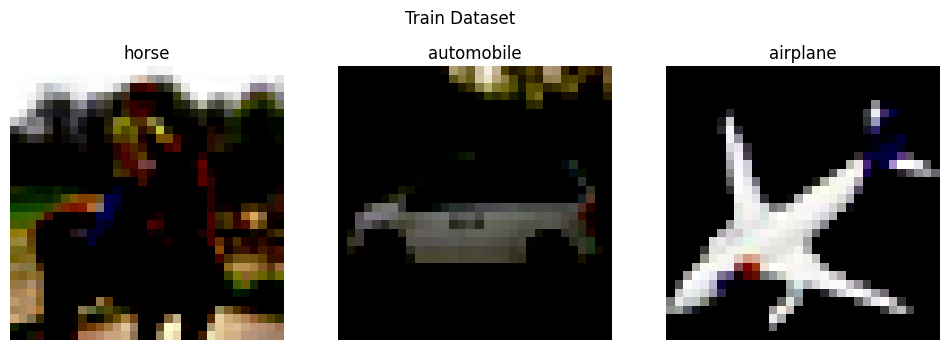

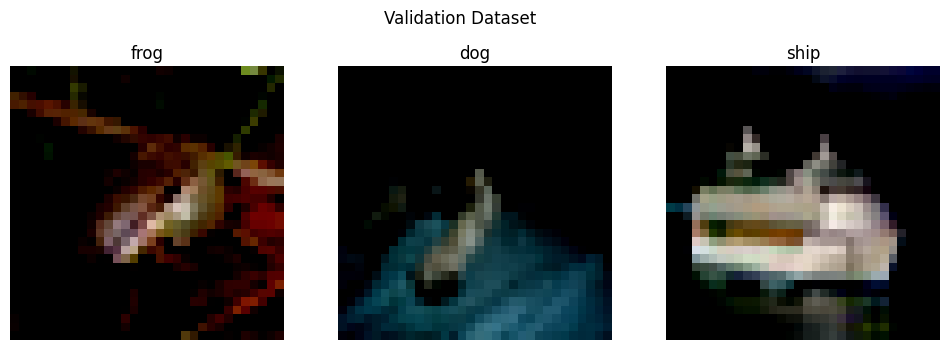

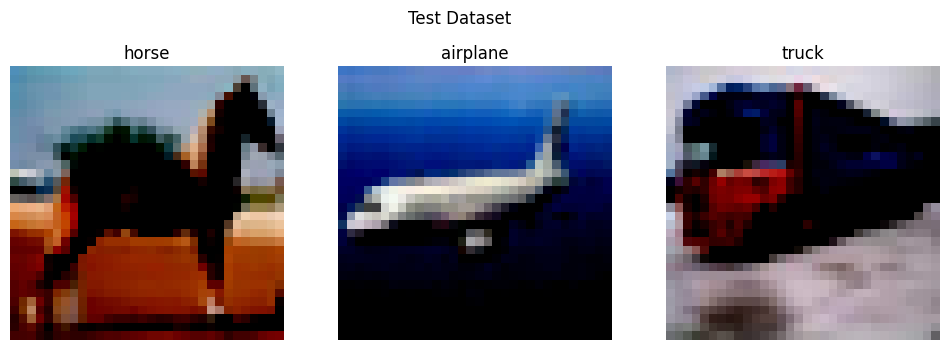

In [6]:
classes = full_train_dataset.classes   # CIFAR-10 class names: cat, dog and etc.

#define a function to show random images
def show_random_images(dataset, dataset_name, classes, num_images=3):
    plt.figure(figsize=(12, 4))   # create a figure

    random_indices = random.sample(range(len(dataset)), num_images)   # choose random indices

    for i, idx in enumerate(random_indices):
        image, label = dataset[idx]   # get image and label

        image = image.permute(1, 2, 0)   # change shape from [C, H, W] to [H, W, C]

        plt.subplot(1, num_images, i + 1)   # create subplot
        plt.imshow(image)   # show image
        plt.title(classes[label])   # show class name
        plt.axis("off")   # hide axes

    plt.suptitle(dataset_name)   # title for whole dataset row
    plt.show()

show_random_images(train_dataset, "Train Dataset", classes, num_images=3)
show_random_images(val_dataset, "Validation Dataset", classes, num_images=3)
show_random_images(test_dataset, "Test Dataset", classes, num_images=3)

# ***Model***

### 🔧 Constrained Convolution Layer
- Does **not optimize weights \( W \) directly**  
- Instead stores **product-manifold parameters** \( (X, Z) \)  
- Reconstructs \( W \) during the forward pass via \( \phi^{-1}(X, Z) \)

---

### 🔄 Shape Convention

`diffeo.phi_inverse` expects:
- \( X_{\text{std}} \in \mathbb{R}^{(\text{rank},\, p)} \)
- \( Z_{\text{std}} \in \mathbb{R}^{(n-\text{rank},\, p)} \)
- Returns \( W \in \mathbb{R}^{(n,\, p)} \)

However, the optimizer requires:
- **rows ≤ cols** (Stiefel format)

So we store:
- \( X \in \mathbb{R}^{(p,\, \text{rank})} \)
- \( Z \in \mathbb{R}^{(p,\, n-\text{rank})} \)

➡️ Transpose is applied inside `forward()` before calling \( \phi^{-1} \)

---

### 🎯 Initialization
- Sample a valid product-manifold point:
  - \( X_{\text{std}} \) with \( X_{\text{std}}^\top X_{\text{std}} = I \)
  - \( Z_{\text{std}} \) unconstrained

---

### 🏗️ CNN Architecture (CIFAR-10)
- `conv1`: **unconstrained**
- `conv2–conv4`: **generalized Stiefel constrained**
  - implemented via product-manifold parameters \( (X, Z) \)

In [8]:
# import torch neural-network functional operations such as conv2d
import torch.nn.functional as F


class ProductGStiefelConv2d(nn.Module):
    def __init__(
        self,
        in_channels: int,              # number of input channels
        out_channels: int,             # number of output channels
        kernel_size: int,              # convolution kernel size
        diffeo,                        # GeneralizedStiefelDiffeomorphismTorch object for this layer
        stride: int = 1,               # convolution stride
        padding: int = 0,              # convolution padding
        bias: bool = True,             # whether to use bias
    ):
        # initialize the parent nn.Module class
        super().__init__()

        # store basic layer information
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding


        self.diffeo = diffeo

        # flattened ambient dimension n = in_channels * kernel_size * kernel_size
        # because each convolution filter is flattened into length n
        self.n = in_channels * kernel_size * kernel_size

        # number of filters p = out_channels
        # so the full flattened weight matrix is interpreted as shape n x p
        self.p = out_channels

        # read the rank of B from the diffeomorphism
        self.rank = diffeo.rank


        X_std, Z_std = diffeo.random_product_point(self.p)

        # store the Stiefel part as a trainable parameter with transposed shape (p, rank)
        self.X = nn.Parameter(X_std.t().contiguous())

        # store the Euclidean part as a trainable parameter with transposed shape (p, n-rank)
        self.Z = nn.Parameter(Z_std.t().contiguous())

        # create an optional trainable bias
        if bias:
            # initialize bias as zeros, same as standard layers often do
            self.bias = nn.Parameter(torch.zeros(out_channels, device=X_std.device, dtype=X_std.dtype))
        else:
            # if no bias is used, register None properly
            self.register_parameter("bias", None)

    def reconstruct_weight(self) -> torch.Tensor:
        # transpose X back to the mathematical shape expected by phi_inverse: (rank, p)
        X_std = self.X.t()

        # transpose Z back to the mathematical shape expected by phi_inverse: (n-rank, p)
        Z_std = self.Z.t()

        # reconstruct the generalized-Stiefel weight in flattened form with shape (n, p)
        W_flat_np = self.diffeo.phi_inverse(X_std, Z_std)

        # transpose from (n, p) to (p, n) so that each row is one convolution filter
        W_flat_pn = W_flat_np.t()

        # reshape the flattened filters into the 4D convolution weight tensor
        W = W_flat_pn.view(
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        )

        # return the reconstructed convolution kernel
        return W

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # reconstruct the current constrained weight from (X, Z)
        W = self.reconstruct_weight()

        # apply 2D convolution manually using the reconstructed weight
        return F.conv2d(
            x,
            W,
            bias=self.bias,
            stride=self.stride,
            padding=self.padding,
        )


class CIFAR10_CNN_Product(nn.Module):
    def __init__(self, phi2, phi3, phi4):
        # initialize the parent nn.Module class
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,             # RGB image input
            out_channels=32,           # produce 32 feature maps
            kernel_size=3,             # 3x3 convolution kernel
            padding=1,                 # keep spatial size the same before pooling
        )

        # ReLU activation after conv1
        self.relu1 = nn.ReLU()

        # max-pooling halves 32x32 -> 16x16
        self.pool1 = nn.MaxPool2d(2, 2)


        self.conv2 = ProductGStiefelConv2d(
            in_channels=32,            # input channels from previous layer
            out_channels=64,           # output feature maps
            kernel_size=3,             # 3x3 kernel
            padding=1,                 # preserve spatial size before pooling
            diffeo=phi2,               # layer-specific generalized Stiefel diffeomorphism
        )

        # ReLU after conv2
        self.relu2 = nn.ReLU()

        # max-pooling halves 16x16 -> 8x8
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = ProductGStiefelConv2d(
            in_channels=64,            # input channels from previous layer
            out_channels=128,          # output feature maps
            kernel_size=3,             # 3x3 kernel
            padding=1,                 # preserve spatial size before pooling
            diffeo=phi3,               # layer-specific generalized Stiefel diffeomorphism
        )

        # ReLU after conv3
        self.relu3 = nn.ReLU()

        # max-pooling halves 8x8 -> 4x4
        self.pool3 = nn.MaxPool2d(2, 2)


        self.conv4 = ProductGStiefelConv2d(
            in_channels=128,           # input channels from previous layer
            out_channels=256,          # output feature maps
            kernel_size=3,             # 3x3 kernel
            padding=1,                 # preserve spatial size before pooling
            diffeo=phi4,               # layer-specific generalized Stiefel diffeomorphism
        )

        # ReLU after conv4
        self.relu4 = nn.ReLU()

        # max-pooling halves 4x4 -> 2x2
        self.pool4 = nn.MaxPool2d(2, 2)

        # flatten 256x2x2 into a vector of length 1024
        self.flatten = nn.Flatten()

        # first fully-connected layer
        self.fc1 = nn.Linear(256 * 2 * 2, 256)

        # ReLU after fc1
        self.relu5 = nn.ReLU()

        # dropout for regularization
        self.drop1 = nn.Dropout(0.2)

        # second fully-connected layer
        self.fc2 = nn.Linear(256, 128)

        # ReLU after fc2
        self.relu6 = nn.ReLU()

        # stronger dropout before final classifier
        self.drop2 = nn.Dropout(0.5)

        # final output layer for 10 CIFAR-10 classes
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # apply first conv block: conv -> relu -> pool
        x = self.pool1(self.relu1(self.conv1(x)))

        # apply second conv block: constrained conv -> relu -> pool
        x = self.pool2(self.relu2(self.conv2(x)))

        # apply third conv block: constrained conv -> relu -> pool
        x = self.pool3(self.relu3(self.conv3(x)))

        # apply fourth conv block: constrained conv -> relu -> pool
        x = self.pool4(self.relu4(self.conv4(x)))

        # flatten convolution output into a batch of vectors
        x = self.flatten(x)

        # apply first dense block
        x = self.relu5(self.fc1(x))

        # apply first dropout
        x = self.drop1(x)

        # apply second dense block
        x = self.relu6(self.fc2(x))

        # apply second dropout
        x = self.drop2(x)

        # produce logits for 10 classes
        x = self.fc3(x)

        # return final network output
        return x



#***Loss Function***

As our probem is classification problem, we use Cross entropy as loss function.

In [9]:
# Define loss function
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss

#***Define matrix B manually***

We should fix matrix $B$ for defining generalized Stiefel manifold.As we do optimization layerwise, we use different metrics ($B$ matrices) for each layer. Requirement for well-defined problem:
* $B_i$ is positive semidefinitive for all $i = 1, 2, 3, 4.$
* $rank(B_1) \geq 32$   # impossible because B1 is only 27x27
* $rank(B_2) \geq 64$
* $rank(B_3) \geq 128$
* $rank(B_4) \geq 256$

In [10]:
# conv1 is not feasible in current row-form setup
B1 = None

dtype = torch.float32

# conv2: size 288 x 288
d2 = torch.linspace(0.5, 3.0, 288, device=device, dtype=dtype)
d2[:40] = 0.0
B2 = torch.diag(d2)

# conv3: size 576 x 576
d3 = torch.linspace(0.2, 2.5, 576, device=device, dtype=dtype)
d3[:80] = 0.0
B3 = torch.diag(d3)

# conv4: size 1152 x 1152
d4 = torch.linspace(0.1, 2.0, 1152, device=device, dtype=dtype)
d4[:120] = 0.0
B4 = torch.diag(d4)

#Saving all weights as a dictionaty
layer_B_map = {
    "conv2.weight": B2,
    "conv3.weight": B3,
    "conv4.weight": B4,
}

In [ ]:
def make_singular_psd(n, rank, device="cpu", dtype=torch.float32, seed=0):
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    A = torch.randn(rank, n, generator=g, device=device, dtype=dtype)
    B = A.t() @ A
    B = 0.5 * (B + B.t())
    return B

B1 = None

# choose rank >= required row count
B2 = make_singular_psd(288, rank=100, device=device, dtype=dtype, seed=1)   # rank 100 >= 64
B3 = make_singular_psd(576, rank=180, device=device, dtype=dtype, seed=2)   # rank 180 >= 128
B4 = make_singular_psd(1152, rank=320, device=device, dtype=dtype, seed=3)  # rank 320 >= 256

#Saving all weights as a dictionaty
layer_B_map = {
    "conv2.weight": B2,
    "conv3.weight": B3,
    "conv4.weight": B4,
}

#***Diffeomorphism***

Define the map
$$
\Phi : \mathrm{St}_B(p,n)
\to
\mathrm{St}(p,r) \times \mathbb{R}^{(n-r)\times p}
$$
by
$$
\boxed{
\Phi(X)
=
\left(
\Lambda^{1/2} X_1,\; X_2
\right)
}
\quad \text{where }
\begin{pmatrix}
X_1 \\
X_2
\end{pmatrix}
= Q^\top X.
$$

---

In [11]:
# import future annotations so type hints can reference the class itself safely
from __future__ import annotations

# import torch for tensor and linear algebra operations
import torch


# ------------------------------------------------------------
# Helper function:
# return the symmetric part of a square matrix
# ------------------------------------------------------------
def sym(A: torch.Tensor) -> torch.Tensor:
    # compute (A + A^T) / 2
    return 0.5 * (A + A.T)


# ------------------------------------------------------------
# Diffeomorphism between generalized Stiefel St_B and a product
# manifold consisting of:
#   - a standard Stiefel part
#   - a Euclidean part
#
# If B = Q diag(Lambda, 0) Q^T with rank r, and W is written as
#
#   Q^T W = [W1]
#           [W2]
#
# then define
#
#   X = Lambda^(1/2) W1
#   Z = W2
#
# and reconstruct by
#
#   W1 = Lambda^(-1/2) X
#   W  = Q1 W1 + Q2 Z
#
# For W in St_B, the Stiefel part satisfies X^T X = I.
# ------------------------------------------------------------
class GeneralizedStiefelDiffeomorphismTorch:
    def __init__(self, B: torch.Tensor, tol: float = 1e-10):
        # store the matrix B
        self.B = B

        # numerical tolerance used for rank decisions and checks
        self.tol = tol

        # store device and dtype for creating compatible tensors later
        self.device = B.device
        self.dtype = B.dtype

        # check that B is square
        if B.ndim != 2 or B.shape[0] != B.shape[1]:
            raise ValueError("B must be a square matrix.")

        # store ambient dimension n
        self.n = B.shape[0]

        # enforce symmetry numerically to avoid tiny asymmetry problems
        Bsym = sym(B)

        # eigen-decomposition of symmetric B
        # eigh is used because B is symmetric
        evals, Q = torch.linalg.eigh(Bsym)

        # sort eigenvalues from largest to smallest
        idx = torch.argsort(evals, descending=True)
        evals = evals[idx]
        Q = Q[:, idx]

        # B must be positive semidefinite, so no significantly negative eigenvalues
        if torch.any(evals < -tol):
            raise ValueError("B must be positive semidefinite.")

        # numerical rank = number of eigenvalues greater than tolerance
        rank = int((evals > tol).sum().item())

        # store rank(B)
        self.rank = rank

        # store full eigenvector matrix
        self.Q = Q

        # store sorted eigenvalues
        self.evals = evals

        # split Q into image-space basis Q1 and null-space basis Q2
        self.Q1 = Q[:, :rank]
        self.Q2 = Q[:, rank:]

        # positive eigenvalues only
        if rank > 0:
            # keep the strictly positive eigenvalues
            lam = evals[:rank]

            # diagonal matrix Lambda
            self.Lambda = torch.diag(lam)

            # diagonal square root Lambda^(1/2)
            self.Lambda_half = torch.diag(torch.sqrt(lam))

            # diagonal inverse square root Lambda^(-1/2)
            self.Lambda_half_inv = torch.diag(1.0 / torch.sqrt(lam))
        else:
            # if rank is zero, create empty matrices with correct shapes
            self.Lambda = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half_inv = torch.empty((0, 0), device=self.device, dtype=self.dtype)

    # --------------------------------------------------------
    # Check whether W belongs to the generalized Stiefel manifold:
    #     W^T B W = I
    # Here W must have shape (n, p)
    # --------------------------------------------------------
    def in_generalized_stiefel(self, W: torch.Tensor) -> bool:
        # check ambient dimension
        if W.ndim != 2 or W.shape[0] != self.n:
            return False

        # number of columns p
        p = W.shape[1]

        # compute W^T B W
        gram = W.T @ self.B @ W

        # compare against identity
        I = torch.eye(p, device=W.device, dtype=W.dtype)

        # return whether the constraint is satisfied up to tolerance
        return torch.norm(gram - I) <= 1e2 * self.tol

    # --------------------------------------------------------
    # Map W in St_B to product coordinates (X, Z)
    #
    # Input:
    #   W : shape (n, p)
    #
    # Output:
    #   X : shape (rank, p)  with X^T X = I if W in St_B
    #   Z : shape (n-rank, p)
    # --------------------------------------------------------
    def phi(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # check shape
        if W.ndim != 2 or W.shape[0] != self.n:
            raise ValueError(f"W must have shape ({self.n}, p).")

        # coordinates of W in the Q basis
        QtW = self.Q.T @ W

        # top block in the range of B
        W1 = QtW[:self.rank, :]

        # bottom block in the null-space of B
        W2 = QtW[self.rank:, :]

        # Stiefel part:
        # X = Lambda^(1/2) W1
        if self.rank > 0:
            X = self.Lambda_half @ W1
        else:
            # if rank is zero, X is empty with 0 rows
            X = torch.empty((0, W.shape[1]), device=W.device, dtype=W.dtype)

        # Euclidean part:
        # Z = W2
        Z = W2

        # return product coordinates
        return X, Z

    # --------------------------------------------------------
    # Inverse map from product coordinates (X, Z) back to W
    #
    # Input:
    #   X : shape (rank, p)
    #   Z : shape (n-rank, p)
    #
    # Output:
    #   W : shape (n, p)
    # --------------------------------------------------------
    def phi_inverse(self, X: torch.Tensor, Z: torch.Tensor) -> torch.Tensor:
        # check dimensions of X
        if X.ndim != 2:
            raise ValueError("X must be a matrix of shape (rank, p).")

        # check dimensions of Z
        if Z.ndim != 2:
            raise ValueError("Z must be a matrix of shape (n-rank, p).")

        # both product blocks must have the same number of columns p
        if X.shape[1] != Z.shape[1]:
            raise ValueError("X and Z must have the same number of columns.")

        # X must have rank rows
        if X.shape[0] != self.rank:
            raise ValueError(f"X must have shape ({self.rank}, p).")

        # Z must have n-rank rows
        if Z.shape[0] != self.n - self.rank:
            raise ValueError(f"Z must have shape ({self.n - self.rank}, p).")

        # reconstruct W1 = Lambda^(-1/2) X
        if self.rank > 0:
            W1 = self.Lambda_half_inv @ X
        else:
            # if rank is zero, W1 is empty
            W1 = torch.empty((0, X.shape[1]), device=X.device, dtype=X.dtype)

        # reconstruct W = Q1 W1 + Q2 Z
        W = self.Q1 @ W1 + self.Q2 @ Z

        # return ambient matrix W in the original coordinates
        return W

    # --------------------------------------------------------
    # Create a valid random point in the product manifold
    #
    # Input:
    #   p : number of columns
    #
    # Output:
    #   X : shape (rank, p), satisfying X^T X = I
    #   Z : shape (n-rank, p), arbitrary Euclidean block
    #
    # Important geometric condition:
    #   for X^T X = I to be possible, we need p <= rank
    # --------------------------------------------------------
    def random_product_point(self, p: int) -> tuple[torch.Tensor, torch.Tensor]:
        # Stiefel part needs rank >= p
        if p > self.rank:
            raise ValueError(
                f"Cannot create a Stiefel point with p={p} columns when rank(B)={self.rank}. "
                "You need p <= rank(B)."
            )

        # ----------------------------------------------------
        # build X in St(rank, p), meaning:
        #   X has shape (rank, p)
        #   X^T X = I_p
        #
        # easiest way:
        #   sample a random rank x p matrix
        #   take reduced QR
        # ----------------------------------------------------
        A = torch.randn(self.rank, p, device=self.device, dtype=self.dtype)

        # reduced QR gives Qx with orthonormal columns
        Qx, Rx = torch.linalg.qr(A, mode="reduced")

        # fix column signs so QR is deterministic up to sign
        d = torch.diagonal(Rx, 0)
        s = torch.sign(d)
        s[s == 0] = 1
        Qx = Qx * s.unsqueeze(0)

        # this is the standard Stiefel variable
        X = Qx

        # Euclidean block can start from zeros
        Z = torch.zeros(self.n - self.rank, p, device=self.device, dtype=self.dtype)

        # return a valid product point
        return X, Z

    # --------------------------------------------------------
    # Initialize product coordinates from an existing W in St_B
    #
    # This is useful if you already have a valid generalized
    # Stiefel point and want to convert it into (X, Z).
    # --------------------------------------------------------
    def init_from_W(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # optionally verify membership
        if not self.in_generalized_stiefel(W):
            raise ValueError("Input W does not satisfy W^T B W = I up to tolerance.")

        # map to product coordinates
        return self.phi(W)

    # --------------------------------------------------------
    # Print a compact summary of the decomposition
    # --------------------------------------------------------
    def print_summary(self) -> None:
        # print ambient dimension
        print(f"n = {self.n}")

        # print rank of B
        print(f"rank(B) = {self.rank}")

        # print positive eigenvalues
        print("positive eigenvalues =", self.evals[:self.rank])

        # print shapes of decomposition blocks
        print("Q1 shape =", tuple(self.Q1.shape))
        print("Q2 shape =", tuple(self.Q2.shape))

In [15]:



# ------------------------------------------------------------
# B2, B3, B4 must already be created in earlier cells.
#
# Their sizes should match the flattened convolution dimensions:
#
# conv2: n2 = 32 * 3 * 3
# conv3: n3 = 64 * 3 * 3
# conv4: n4 = 128 * 3 * 3
#
# and the corresponding numbers of filters are:
#
# conv2: p2 = 64
# conv3: p3 = 128
# conv4: p4 = 256
# ------------------------------------------------------------

# move each B matrix to the same device and dtype that the model will use
# float32 is the usual training dtype for CNNs
B2 = B2.to(device=device, dtype=torch.float32)
B3 = B3.to(device=device, dtype=torch.float32)
B4 = B4.to(device=device, dtype=torch.float32)


# ------------------------------------------------------------
# build one generalized-Stiefel diffeomorphism per constrained layer
# ------------------------------------------------------------

# diffeomorphism object for conv2
phi2 = GeneralizedStiefelDiffeomorphismTorch(B2)

# diffeomorphism object for conv3
phi3 = GeneralizedStiefelDiffeomorphismTorch(B3)

# diffeomorphism object for conv4
phi4 = GeneralizedStiefelDiffeomorphismTorch(B4)


# ------------------------------------------------------------
# define the number of filters p for each constrained layer
# these are the column counts in the mathematical formulation
# ------------------------------------------------------------

# conv2 has 64 output filters
p2 = 64

# conv3 has 128 output filters
p3 = 128

# conv4 has 256 output filters
p4 = 256


# ------------------------------------------------------------
# check the necessary condition for the product construction:
#
# for X in St(rank(B), p), we must have p <= rank(B)
# ------------------------------------------------------------

# verify conv2 rank condition
if phi2.rank < p2:
    raise ValueError(
        f"conv2 is not feasible: rank(B2)={phi2.rank} but p2={p2}. "
        "You need rank(B2) >= number of conv2 filters."
    )

# verify conv3 rank condition
if phi3.rank < p3:
    raise ValueError(
        f"conv3 is not feasible: rank(B3)={phi3.rank} but p3={p3}. "
        "You need rank(B3) >= number of conv3 filters."
    )

# verify conv4 rank condition
if phi4.rank < p4:
    raise ValueError(
        f"conv4 is not feasible: rank(B4)={phi4.rank} but p4={p4}. "
        "You need rank(B4) >= number of conv4 filters."
    )


# ------------------------------------------------------------
# print a short summary so you can verify the geometry
# ------------------------------------------------------------

# show the ambient dimension and rank for conv2
print(f"conv2: n = {phi2.n}, rank(B2) = {phi2.rank}, p = {p2}")

# show the ambient dimension and rank for conv3
print(f"conv3: n = {phi3.n}, rank(B3) = {phi3.rank}, p = {p3}")

# show the ambient dimension and rank for conv4
print(f"conv4: n = {phi4.n}, rank(B4) = {phi4.rank}, p = {p4}")


# ------------------------------------------------------------
# create the CNN model that uses:
#   - ordinary conv1
#   - constrained conv2, conv3, conv4
# each constrained layer internally stores (X, Z) and
# reconstructs its actual weight by phi_inverse(X, Z)
# ------------------------------------------------------------

# instantiate the product-manifold CNN
model = CIFAR10_CNN_Product(phi2, phi3, phi4).to(device)

# print the model structure
print(model)


# ------------------------------------------------------------
# optional sanity checks:
# inspect the shapes of the trainable product variables
# ------------------------------------------------------------

# conv2 product variables
print("conv2.X shape =", tuple(model.conv2.X.shape))
print("conv2.Z shape =", tuple(model.conv2.Z.shape))

# conv3 product variables
print("conv3.X shape =", tuple(model.conv3.X.shape))
print("conv3.Z shape =", tuple(model.conv3.Z.shape))

# conv4 product variables
print("conv4.X shape =", tuple(model.conv4.X.shape))
print("conv4.Z shape =", tuple(model.conv4.Z.shape))


# ------------------------------------------------------------
# optional reconstruction check:
# rebuild one constrained weight and inspect its shape
# ------------------------------------------------------------

# reconstruct conv2 weight tensor from (X, Z)
W2 = model.conv2.reconstruct_weight()

# reconstruct conv3 weight tensor from (X, Z)
W3 = model.conv3.reconstruct_weight()

# reconstruct conv4 weight tensor from (X, Z)
W4 = model.conv4.reconstruct_weight()

# print reconstructed convolution kernel shapes
print("reconstructed conv2 weight shape =", tuple(W2.shape))
print("reconstructed conv3 weight shape =", tuple(W3.shape))
print("reconstructed conv4 weight shape =", tuple(W4.shape))

conv2: n = 288, rank(B2) = 248, p = 64
conv3: n = 576, rank(B3) = 496, p = 128
conv4: n = 1152, rank(B4) = 1032, p = 256
CIFAR10_CNN_Product(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): ProductGStiefelConv2d()
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): ProductGStiefelConv2d()
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): ProductGStiefelConv2d()
  (relu4): ReLU()
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (relu5): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu6): ReLU()
  (drop2): Dr

#***Optimization Method***
We restrict weight parameters to Generalized Stiefel manifold and update this manifold first few epoch and then we fix "learned metric" then do optimization. We do not apply these method to all parameters so first we split paramaters two groups: `stifel_params` and `normal_params.`

In [20]:
with open("stiefel_optimizer_modify.py", "r") as f:
    code = f.read()

# replace tabs with 4 spaces
code = code.replace("\t", "    ")

with open("stiefel_optimizer_modify.py", "w") as f:
    f.write(code)

In [23]:
file_path = "stiefel_optimizer_modify.py"

with open(file_path, "r") as f:
    code = f.read()

# fix tabs → spaces
code = code.replace("\t", "    ")

# fix SGDG block
code = code.replace(
"G = p.grad.data.view(p.size(0), -1)\n            g = stiefel_proj_tan(unity, G)\n            lr = group['lr']",
"        G = p.grad.data.view(p.size(0), -1)\n        g = stiefel_proj_tan(unity, G)\n        lr = group['lr']"
)

# fix AdamG block
code = code.replace(
"G = p.grad.data.view(p.size(0), -1)\n            g = stiefel_proj_tan(unity, G)",
"        G = p.grad.data.view(p.size(0), -1)\n        g = stiefel_proj_tan(unity, G)"
)

with open(file_path, "w") as f:
    f.write(code)

print("Fixed!")

Fixed!


In [26]:
!pip install nested_dict



# choose the learning rate for the Stiefel part
LR_STIEFEL = 0.005

# choose the learning rate for the Euclidean part
LR_EUCLID = 0.01

# momentum coefficient for SGD-style optimizers
MOMENTUM = 0.9

# weight decay for ordinary Euclidean parameters
WEIGHT_DECAY = 1e-4


# ------------------------------------------------------------
# collect the Stiefel product variables X from the constrained layers
# these are the variables optimized on the standard Stiefel manifold
# ------------------------------------------------------------

# conv2 Stiefel variable
stiefel_params = [model.conv2.X]

# add conv3 Stiefel variable
stiefel_params.append(model.conv3.X)

# add conv4 Stiefel variable
stiefel_params.append(model.conv4.X)


# ------------------------------------------------------------
# collect the Euclidean product variables Z from the constrained layers
# these are optimized in ordinary Euclidean space
# ------------------------------------------------------------

# conv2 Euclidean variable
product_z_params = [model.conv2.Z]

# add conv3 Euclidean variable
product_z_params.append(model.conv3.Z)

# add conv4 Euclidean variable
product_z_params.append(model.conv4.Z)


# ------------------------------------------------------------
# collect all ordinary unconstrained network parameters
#
# IMPORTANT:
# we must EXCLUDE:
#   - constrained X variables
#   - constrained Z variables
#
# because those are already handled explicitly above
# ------------------------------------------------------------

# create a set of Python ids for all constrained product parameters
# this lets us filter them out from model.parameters()
product_param_ids = {id(p) for p in stiefel_params + product_z_params}

# collect every parameter in the model that is NOT one of the product parameters
# these are ordinary Euclidean parameters such as:
#   conv1 weights and bias
#   fc1, fc2, fc3 weights and biases
#   constrained-layer biases if present
other_params = [
    p for p in model.parameters()
    if id(p) not in product_param_ids
]


# ------------------------------------------------------------
# combine all Euclidean parameters into one list:
#   - Z variables from product coordinates
#   - all ordinary unconstrained model parameters
# ------------------------------------------------------------

# final Euclidean parameter list
euclid_params = product_z_params + other_params


# ------------------------------------------------------------
# print parameter counts for sanity checking
# ------------------------------------------------------------

# count number of tensors in the Stiefel block
print("number of Stiefel parameter tensors =", len(stiefel_params))

# count number of tensors in the Euclidean block
print("number of Euclidean parameter tensors =", len(euclid_params))

# print the shapes of the Stiefel variables
for i, p in enumerate(stiefel_params, start=2):
    print(f"conv{i}.X shape = {tuple(p.shape)}")

# print the shapes of the Z variables
for i, p in enumerate(product_z_params, start=2):
    print(f"conv{i}.Z shape = {tuple(p.shape)}")



# import the Stiefel optimizer class from your optimizer file
from stiefel_optimizer_modify import SGDG

# build the optimizer for the Stiefel variables only
stiefel_optimizer = SGDG(
    [
        {
            "params": stiefel_params,      # only X variables live on the Stiefel manifold
            "lr": LR_STIEFEL,              # Stiefel learning rate
            "stiefel": True,               # activate the manifold-aware branch
            "weight_decay": 0.0,           # usually keep this zero first for the Stiefel block
            "eps": 1e-8,                   # numerical stabilization
            "reorthogonalize": True,      # start without extra QR cleanup
        }
    ]
)



# use standard SGD with momentum in Euclidean space
euclid_optimizer = torch.optim.SGD(
    euclid_params,                         # Z variables + ordinary unconstrained parameters
    lr=LR_EUCLID,                         # Euclidean learning rate
    momentum=MOMENTUM,                    # momentum coefficient
    weight_decay=WEIGHT_DECAY,            # L2 regularization
)


-

# show the Stiefel optimizer
print("stiefel_optimizer =", stiefel_optimizer)

# show the Euclidean optimizer
print("euclid_optimizer =", euclid_optimizer)

number of Stiefel parameter tensors = 3
number of Euclidean parameter tensors = 14
conv2.X shape = (64, 248)
conv3.X shape = (128, 496)
conv4.X shape = (256, 1032)
conv2.Z shape = (64, 40)
conv3.Z shape = (128, 80)
conv4.Z shape = (256, 120)
stiefel_optimizer = SGDG (
Parameter Group 0
    dampening: 0
    eps: 1e-08
    grad_clip: None
    lr: 0.005
    momentum: 0
    nesterov: False
    omega: 0
    reorthogonalize: True
    stiefel: True
    weight_decay: 0.0
)
euclid_optimizer = SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)


#***Optimization on Product Manifold***

The clean way is to make one optimizer class for the product variable
$(𝑋,𝑍)$ while letting us plug in a separate update rule for each component.
Below :
* $X∈St(p,r)$ is the Stiefel part
* $Z\in R ^{(n−r)×p}$ is the Euclidean part.

So we can later plug in:
Cayley / QR / retraction GD on the Stiefel part,
SGD / Adam / Lion on the Euclidean part.

#***Training***
We store training and validation's loss and accuracy in per epoch. And visualize them as a plot graph.

In [ ]:


# set the number of training epochs
num_epochs = 15

# create empty lists to store the average training loss and accuracy per epoch
train_losses = []
train_accuracies = []

# create empty lists to store the average validation loss and accuracy per epoch
val_losses = []
val_accuracies = []

# create empty lists to store standard Stiefel constraint errors for X variables
stiefel_err_conv2 = []
stiefel_err_conv3 = []
stiefel_err_conv4 = []

# create empty lists to store generalized Stiefel constraint errors
# for the reconstructed weights W
gstiefel_err_conv2 = []
gstiefel_err_conv3 = []
gstiefel_err_conv4 = []

# ------------------------------------------------------------
# start the outer training loop over epochs
# ------------------------------------------------------------
for epoch in range(num_epochs):
    # put the model in training mode
    # this activates dropout and any other train-time behavior
    model.train()

    # initialize running sum of training loss for this epoch
    running_loss = 0.0

    # initialize count of correctly classified training samples
    running_correct = 0

    # initialize total number of training samples seen in this epoch
    running_total = 0

    # --------------------------------------------------------
    # loop over mini-batches from the training loader
    # --------------------------------------------------------
    for images, labels in train_loader:
        # move the input images to the selected device
        images = images.to(device)

        # move the labels to the selected device
        labels = labels.to(device)

        # ----------------------------------------------------
        # clear old gradients from BOTH optimizers
        # this is necessary because PyTorch accumulates gradients
        # ----------------------------------------------------
        stiefel_optimizer.zero_grad()
        euclid_optimizer.zero_grad()

        # ----------------------------------------------------
        # forward pass:
        # inside the constrained layers, each weight is rebuilt
        # from the current product coordinates (X, Z)
        # ----------------------------------------------------
        outputs = model(images)

        # compute the classification loss
        loss = criterion(outputs, labels)

        # ----------------------------------------------------
        # backward pass:
        # autograd computes gradients for all trainable parameters
        #
        # this includes:
        #   - gradients for X variables
        #   - gradients for Z variables
        #   - gradients for ordinary parameters
        # ----------------------------------------------------
        loss.backward()

        # ----------------------------------------------------
        # update the Stiefel variables X
        # this optimizer performs Cayley-based manifold updates
        # ----------------------------------------------------
        stiefel_optimizer.step()

        # ----------------------------------------------------
        # update the Euclidean variables Z and all ordinary params
        # ----------------------------------------------------
        euclid_optimizer.step()

        # ----------------------------------------------------
        # accumulate training statistics
        # ----------------------------------------------------

        # add this batch loss to the running loss
        # multiply by batch size so later we can divide by total samples
        running_loss += loss.item() * images.size(0)

        # find the predicted class with the largest output logit
        _, predicted = torch.max(outputs, dim=1);

        # count how many predictions are correct in this batch
        running_correct += (predicted == labels).sum().item()

        # add batch size to total number of samples seen
        running_total += labels.size(0)

    # --------------------------------------------------------
    # compute average training metrics for the epoch
    # --------------------------------------------------------

    # average training loss over all samples in this epoch
    epoch_train_loss = running_loss / running_total

    # average training accuracy over all samples in this epoch
    epoch_train_acc = running_correct / running_total

    # store the epoch training loss
    train_losses.append(epoch_train_loss)

    # store the epoch training accuracy
    train_accuracies.append(epoch_train_acc)

    # --------------------------------------------------------
    # validation phase
    # --------------------------------------------------------

    # put the model in evaluation mode
    # this disables dropout and other train-time randomness
    model.eval()

    # initialize running sum of validation loss
    val_running_loss = 0.0

    # initialize count of correctly classified validation samples
    val_running_correct = 0

    # initialize total number of validation samples
    val_running_total = 0

    # disable gradient tracking during validation
    # this saves memory and computation
    with torch.no_grad():
        # loop over mini-batches from the validation loader
        for images, labels in val_loader:
            # move validation images to device
            images = images.to(device)

            # move validation labels to device
            labels = labels.to(device)

            # forward pass through the model
            outputs = model(images)

            # compute validation loss
            loss = criterion(outputs, labels)

            # accumulate validation loss weighted by batch size
            val_running_loss += loss.item() * images.size(0)

            # get predicted class indices
            _, predicted = torch.max(outputs, dim=1)

            # count correct predictions
            val_running_correct += (predicted == labels).sum().item()

            # update total number of validation samples
            val_running_total += labels.size(0)

    # compute average validation loss
    epoch_val_loss = val_running_loss / val_running_total

    # compute average validation accuracy
    epoch_val_acc = val_running_correct / val_running_total

    # store validation metrics
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

        # --------------------------------------------------------
    # geometric diagnostics at the end of the epoch
    # --------------------------------------------------------
    with torch.no_grad():
        # ---------- conv2 ----------
        # convert stored X parameter from shape (p, rank) to standard shape (rank, p)
        X2_std = model.conv2.X.t()

        # create identity matrix of size p x p for conv2
        I2 = torch.eye(X2_std.shape[1], device=X2_std.device, dtype=X2_std.dtype)

        # compute standard Stiefel error ||X^T X - I||_F for conv2
        err_st2 = torch.norm(X2_std.t() @ X2_std - I2).item()

        # reconstruct conv2 weight and flatten it to shape (n, p)
        W2_flat = model.conv2.reconstruct_weight().view(model.conv2.out_channels, -1).t()

        # compute generalized Stiefel error ||W^T B W - I||_F for conv2
        err_gst2 = torch.norm(W2_flat.t() @ phi2.B @ W2_flat - I2).item()

        # ---------- conv3 ----------
        # convert stored X parameter from shape (p, rank) to standard shape (rank, p)
        X3_std = model.conv3.X.t()

        # create identity matrix of size p x p for conv3
        I3 = torch.eye(X3_std.shape[1], device=X3_std.device, dtype=X3_std.dtype)

        # compute standard Stiefel error ||X^T X - I||_F for conv3
        err_st3 = torch.norm(X3_std.t() @ X3_std - I3).item()

        # reconstruct conv3 weight and flatten it to shape (n, p)
        W3_flat = model.conv3.reconstruct_weight().view(model.conv3.out_channels, -1).t()

        # compute generalized Stiefel error ||W^T B W - I||_F for conv3
        err_gst3 = torch.norm(W3_flat.t() @ phi3.B @ W3_flat - I3).item()

        # ---------- conv4 ----------
        # convert stored X parameter from shape (p, rank) to standard shape (rank, p)
        X4_std = model.conv4.X.t()

        # create identity matrix of size p x p for conv4
        I4 = torch.eye(X4_std.shape[1], device=X4_std.device, dtype=X4_std.dtype)

        # compute standard Stiefel error ||X^T X - I||_F for conv4
        err_st4 = torch.norm(X4_std.t() @ X4_std - I4).item()

        # reconstruct conv4 weight and flatten it to shape (n, p)
        W4_flat = model.conv4.reconstruct_weight().view(model.conv4.out_channels, -1).t()

        # compute generalized Stiefel error ||W^T B W - I||_F for conv4
        err_gst4 = torch.norm(W4_flat.t() @ phi4.B @ W4_flat - I4).item()

    # store standard Stiefel errors for later plotting
    stiefel_err_conv2.append(err_st2)
    stiefel_err_conv3.append(err_st3)
    stiefel_err_conv4.append(err_st4)

    # store generalized Stiefel errors for later plotting
    gstiefel_err_conv2.append(err_gst2)
    gstiefel_err_conv3.append(err_gst3)
    gstiefel_err_conv4.append(err_gst4)

    # --------------------------------------------------------
    # print a summary line for the current epoch
    # --------------------------------------------------------
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )


Epoch [1/15] | Train Loss: 2.1157 | Train Acc: 0.1943 | Val Loss: 1.7271 | Val Acc: 0.3528
Epoch [2/15] | Train Loss: 1.6109 | Train Acc: 0.3952 | Val Loss: 1.3958 | Val Acc: 0.4896
Epoch [3/15] | Train Loss: 1.3824 | Train Acc: 0.4921 | Val Loss: 1.2640 | Val Acc: 0.5334
Epoch [4/15] | Train Loss: 1.2378 | Train Acc: 0.5524 | Val Loss: 1.1165 | Val Acc: 0.5992
Epoch [5/15] | Train Loss: 1.1182 | Train Acc: 0.5984 | Val Loss: 1.0852 | Val Acc: 0.6129
Epoch [6/15] | Train Loss: 1.0244 | Train Acc: 0.6399 | Val Loss: 0.9759 | Val Acc: 0.6509
Epoch [7/15] | Train Loss: 0.9425 | Train Acc: 0.6692 | Val Loss: 0.9583 | Val Acc: 0.6552
Epoch [8/15] | Train Loss: 0.8703 | Train Acc: 0.6962 | Val Loss: 0.9066 | Val Acc: 0.6774
Epoch [9/15] | Train Loss: 0.8036 | Train Acc: 0.7209 | Val Loss: 0.9019 | Val Acc: 0.6862
Epoch [10/15] | Train Loss: 0.7378 | Train Acc: 0.7449 | Val Loss: 0.9072 | Val Acc: 0.6871


#***Testing***
After training we test our model on test dataset.

In [ ]:
# ------------------------------------------------------------
# Test / evaluation cell for the product-manifold CNN
#
# This cell:
#   1. evaluates test loss
#   2. evaluates test accuracy
#   3. checks manifold constraint errors
#   4. optionally computes per-class accuracy
# ------------------------------------------------------------

# put the model in evaluation mode
# this disables dropout and other training-time randomness
model.eval()

# initialize running sum of test loss
test_running_loss = 0.0

# initialize number of correct predictions on the test set
test_running_correct = 0

# initialize total number of test samples
test_running_total = 0

# CIFAR-10 class names for optional per-class reporting
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# create dictionaries to count correct predictions per class
class_correct = {cls_name: 0 for cls_name in classes}

# create dictionaries to count total samples per class
class_total = {cls_name: 0 for cls_name in classes}

# disable gradient tracking during testing
# this saves memory and speeds up evaluation
with torch.no_grad():
    # loop over test mini-batches
    for images, labels in test_loader:
        # move images to the selected device
        images = images.to(device)

        # move labels to the selected device
        labels = labels.to(device)

        # forward pass through the model
        outputs = model(images)

        # compute the batch loss
        loss = criterion(outputs, labels)

        # add batch loss weighted by batch size
        test_running_loss += loss.item() * images.size(0)

        # get predicted class indices from the output logits
        _, predicted = torch.max(outputs, dim=1)

        # count how many predictions are correct in this batch
        test_running_correct += (predicted == labels).sum().item()

        # update total number of tested samples
        test_running_total += labels.size(0)

        # update per-class counts
        for true_label, pred_label in zip(labels, predicted):
            # convert label index to Python integer
            true_idx = true_label.item()

            # map class index to class name
            cls_name = classes[true_idx]

            # count one more sample for this true class
            class_total[cls_name] += 1

            # if prediction is correct, count one more correct sample
            if pred_label.item() == true_idx:
                class_correct[cls_name] += 1

# compute average test loss
test_loss = test_running_loss / test_running_total

# compute average test accuracy
test_accuracy = test_running_correct / test_running_total

# print overall test metrics
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.9499
Test Accuracy: 0.7084


In [ ]:
# ------------------------------------------------------------
# Geometric checks after testing
#
# We verify:
#   1. standard Stiefel error for X variables
#   2. generalized Stiefel error for reconstructed weights
# ------------------------------------------------------------

with torch.no_grad():
    # ---------- conv2 ----------
    # transpose stored X parameter to the standard Stiefel shape (rank, p)
    X2_std = model.conv2.X.t()

    # identity matrix for conv2
    I2 = torch.eye(X2_std.shape[1], device=X2_std.device, dtype=X2_std.dtype)

    # compute standard Stiefel error ||X^T X - I||_F
    stiefel_err2 = torch.norm(X2_std.t() @ X2_std - I2).item()

    # reconstruct conv2 weight and flatten it to shape (n, p)
    W2_flat = model.conv2.reconstruct_weight().view(model.conv2.out_channels, -1).t()

    # compute generalized Stiefel error ||W^T B W - I||_F
    gstiefel_err2 = torch.norm(W2_flat.t() @ phi2.B @ W2_flat - I2).item()

    # ---------- conv3 ----------
    # transpose stored X parameter to the standard Stiefel shape (rank, p)
    X3_std = model.conv3.X.t()

    # identity matrix for conv3
    I3 = torch.eye(X3_std.shape[1], device=X3_std.device, dtype=X3_std.dtype)

    # compute standard Stiefel error ||X^T X - I||_F
    stiefel_err3 = torch.norm(X3_std.t() @ X3_std - I3).item()

    # reconstruct conv3 weight and flatten it to shape (n, p)
    W3_flat = model.conv3.reconstruct_weight().view(model.conv3.out_channels, -1).t()

    # compute generalized Stiefel error ||W^T B W - I||_F
    gstiefel_err3 = torch.norm(W3_flat.t() @ phi3.B @ W3_flat - I3).item()

    # ---------- conv4 ----------
    # transpose stored X parameter to the standard Stiefel shape (rank, p)
    X4_std = model.conv4.X.t()

    # identity matrix for conv4
    I4 = torch.eye(X4_std.shape[1], device=X4_std.device, dtype=X4_std.dtype)

    # compute standard Stiefel error ||X^T X - I||_F
    stiefel_err4 = torch.norm(X4_std.t() @ X4_std - I4).item()

    # reconstruct conv4 weight and flatten it to shape (n, p)
    W4_flat = model.conv4.reconstruct_weight().view(model.conv4.out_channels, -1).t()

    # compute generalized Stiefel error ||W^T B W - I||_F
    gstiefel_err4 = torch.norm(W4_flat.t() @ phi4.B @ W4_flat - I4).item()

# print standard Stiefel errors
print("\nStandard Stiefel errors:")
print(f"conv2 ||X^T X - I||_F = {stiefel_err2:.6e}")
print(f"conv3 ||X^T X - I||_F = {stiefel_err3:.6e}")
print(f"conv4 ||X^T X - I||_F = {stiefel_err4:.6e}")

# print generalized Stiefel errors
print("\nGeneralized Stiefel errors:")
print(f"conv2 ||W^T B W - I||_F = {gstiefel_err2:.6e}")
print(f"conv3 ||W^T B W - I||_F = {gstiefel_err3:.6e}")
print(f"conv4 ||W^T B W - I||_F = {gstiefel_err4:.6e}")


Standard Stiefel errors:
conv2 ||X^T X - I||_F = 1.769423e-06
conv3 ||X^T X - I||_F = 4.740075e-06
conv4 ||X^T X - I||_F = 4.626605e-06

Generalized Stiefel errors:
conv2 ||W^T B W - I||_F = 1.910599e-06
conv3 ||W^T B W - I||_F = 4.823233e-06
conv4 ||W^T B W - I||_F = 4.722489e-06


In [ ]:
# ------------------------------------------------------------
# Optional: per-class test accuracy
# ------------------------------------------------------------

print("\nPer-class test accuracy:")

for cls_name in classes:
    # avoid division by zero just in case
    if class_total[cls_name] > 0:
        # compute accuracy for this class
        acc = class_correct[cls_name] / class_total[cls_name]
        print(f"{cls_name:>5s}: {acc:.4f}")
    else:
        print(f"{cls_name:>5s}: no samples")


Per-class test accuracy:
plane: 0.8280
  car: 0.8490
 bird: 0.6130
  cat: 0.5310
 deer: 0.6330
  dog: 0.4840
 frog: 0.7890
horse: 0.8080
 ship: 0.7390
truck: 0.8100


In [ ]:
with torch.no_grad():
  total_loss_test_cayAdam = 0
  total_acc_test_cayAdam = 0
  for inputs, labels in test_loader:
    inputs = inputs.to(device)  # Move inputs to the correct device
    labels = labels.to(device)  # Move labels to the correct device
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test_cayAdam += acc
    test_loss = criterion(predictions, labels)
    total_loss_test_cayAdam += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test_cayAdam/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test_cayAdam/len(test_loader), 4)}")

Accuracy Score is: 70.84 and Loss is 0.9496


#***Plotting results***
We plot loss and accuracy of training and validation data set. There will be two kind of problems: overfitting and underfitting.

## Overfitting and Underfitting

### Overfitting
Overfitting occurs when a model learns the training data too closely, including noise and unnecessary details. Because of this, it performs very well on training data but poorly on new, unseen data.

**Common signs:**
- High training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use more training data
- Reduce model complexity
- Apply regularization
- Use dropout
- Stop training early

---

### Underfitting
Underfitting occurs when a model is too simple to learn the underlying patterns in the data. As a result, it performs poorly on both training data and unseen data.

**Common signs:**
- Low training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use a more powerful model
- Train for more epochs
- Add better input features
- Reduce excessive regularization

---

### Summary
- **Overfitting:** good performance on training data, poor performance on new data  
- **Underfitting:** poor performance on both training data and new data

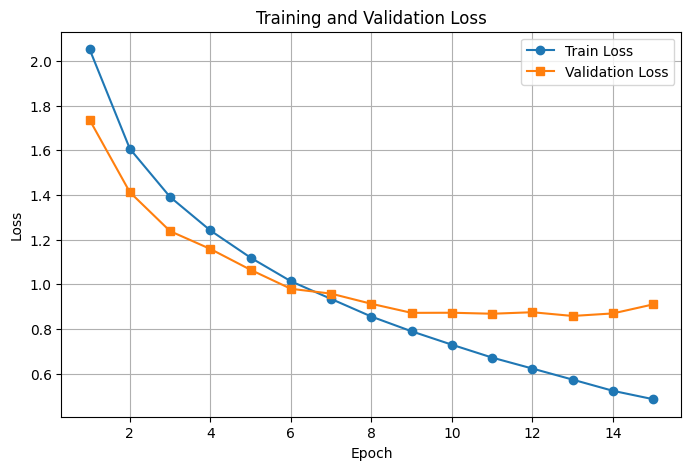

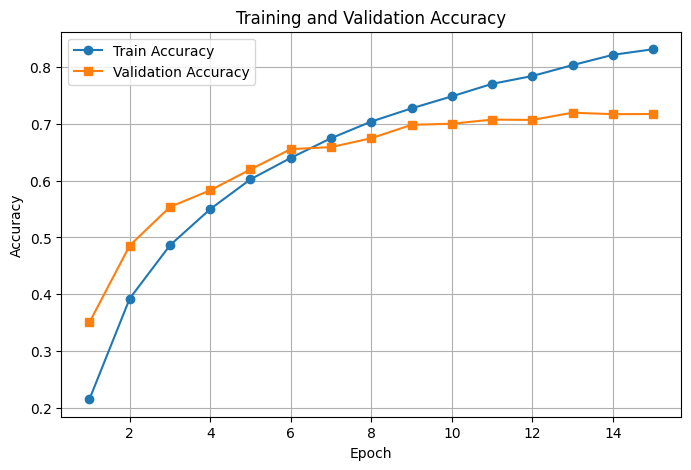

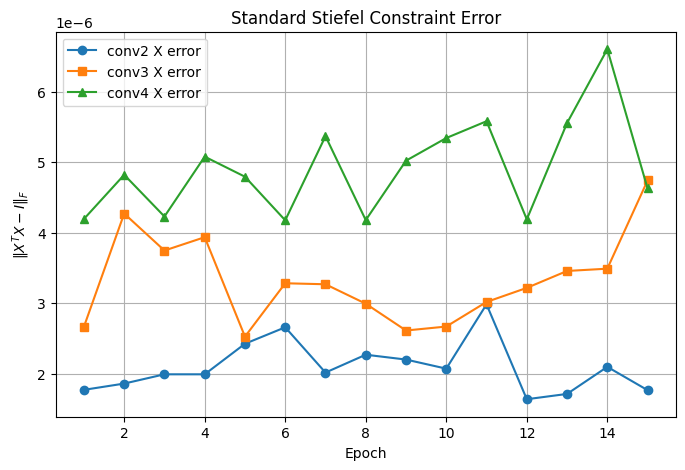

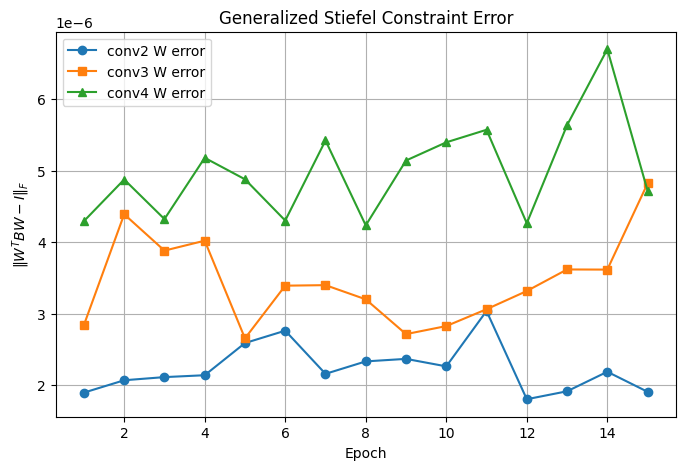

In [ ]:
# ------------------------------------------------------------
# Plotting cell:
# show loss, accuracy, and manifold constraint errors
# ------------------------------------------------------------

# import matplotlib for plotting
import matplotlib.pyplot as plt

# create the list of epoch indices starting from 1
epochs = range(1, len(train_losses) + 1)


# ------------------------------------------------------------
# plot training and validation loss
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# plot training and validation accuracy
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# plot standard Stiefel errors for the X variables
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, stiefel_err_conv2, marker='o', label='conv2 X error')
plt.plot(epochs, stiefel_err_conv3, marker='s', label='conv3 X error')
plt.plot(epochs, stiefel_err_conv4, marker='^', label='conv4 X error')
plt.xlabel('Epoch')
plt.ylabel(r'$\|X^T X - I\|_F$')
plt.title('Standard Stiefel Constraint Error')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# plot generalized Stiefel errors for the reconstructed weights
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, gstiefel_err_conv2, marker='o', label='conv2 W error')
plt.plot(epochs, gstiefel_err_conv3, marker='s', label='conv3 W error')
plt.plot(epochs, gstiefel_err_conv4, marker='^', label='conv4 W error')
plt.xlabel('Epoch')
plt.ylabel(r'$\|W^T B W - I\|_F$')
plt.title('Generalized Stiefel Constraint Error')
plt.legend()
plt.grid(True)
plt.show()